# Titanic data science project
https://www.kaggle.com/c/titanic


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
from os import path

train_path = path.join('datasets', 'titanic', 'train.csv')
test_path = path.join('datasets', 'titanic', 'test.csv')

In [30]:
train_data = pd.read_csv(train_path)
display(train_data.sample(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
842,843,1,1,"Serepeca, Miss. Augusta",female,30.00,0,0,113798,31.0000,NaN,C
830,831,1,3,"Yasbeck, Mrs. Antoni (Selini Alexander)",female,15.00,1,0,2659,14.4542,NaN,C
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.00,0,0,113783,26.5500,C103,S
791,792,0,2,"Gaskell, Mr. Alfred",male,16.00,0,0,239865,26.0000,NaN,S
550,551,1,1,"Thayer, Mr. John Borland Jr",male,17.00,0,2,17421,110.8833,C70,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
17,18,1,2,"Williams, Mr. Charles Eugene",male,NaN,0,0,244373,13.0000,NaN,S
166,167,1,1,"Chibnall, Mrs. (Edith Martha Bowerman)",female,NaN,0,1,113505,55.0000,E33,S
415,416,0,3,"Meek, Mrs. Thomas (Annie Louise Rowley)",female,NaN,0,0,343095,8.0500,NaN,S
561,562,0,3,"Sivic, Mr. Husein",male,40.00,0,0,349251,7.8958,NaN,S


In [31]:
test_data = pd.read_csv(test_path)
display(test_data.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [32]:
print(f"Train data shape: {train_data.shape}, Test data shape: {test_data.shape}")
display(train_data.describe(include='all'))
print(train_data.info())

Train data shape: (891, 12), Test data shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


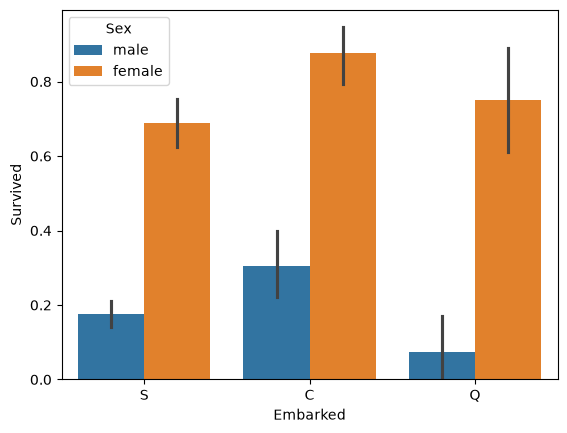

In [33]:
sns.barplot(x='Embarked', y='Survived', hue='Sex', data=train_data)
plt.show()

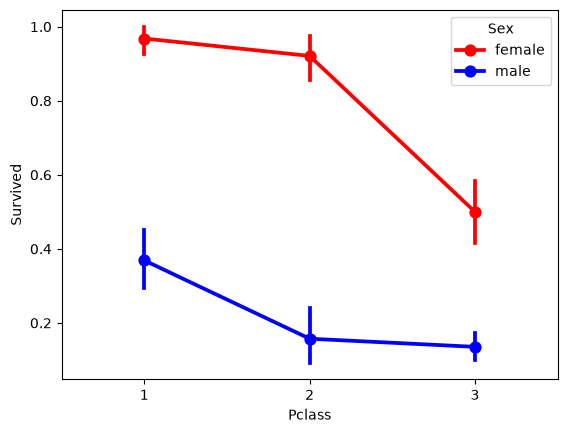

In [34]:
sns.pointplot(x='Pclass', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'red'}, data=train_data)
plt.show()

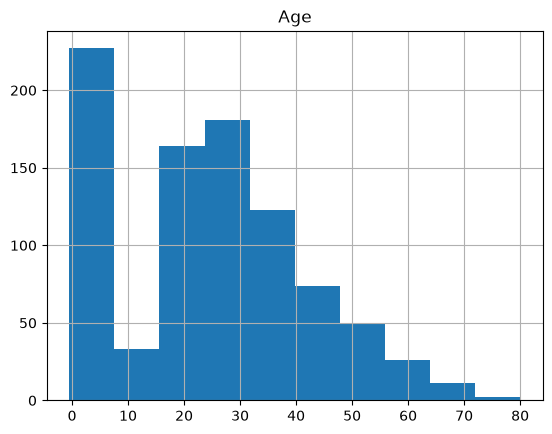

In [45]:
train_data.hist(column='Age')
plt.show()

In [66]:
# Function to categorize age into different age groups
def cat_age(data):
  data['Age'] = data['Age'].fillna(-0.5)
  bins = [-1, 0, 5, 12, 18, 25, 35, 60, 120]
  labels = ['Missing', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']
  data['Age_cat'] = pd.cut(data['Age'], bins=bins, labels=labels)
  return

In [67]:
cat_age(train_data)
cat_age(test_data)

train_data['Age_cat'].sample(10)

602    Missing
605      Adult
50       Child
692    Missing
714      Adult
464    Missing
243    Student
341    Student
115    Student
685    Student
Name: Age_cat, dtype: category
Categories (8, str): ['Missing' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'Young Adult' < 'Adult' < 'Senior']

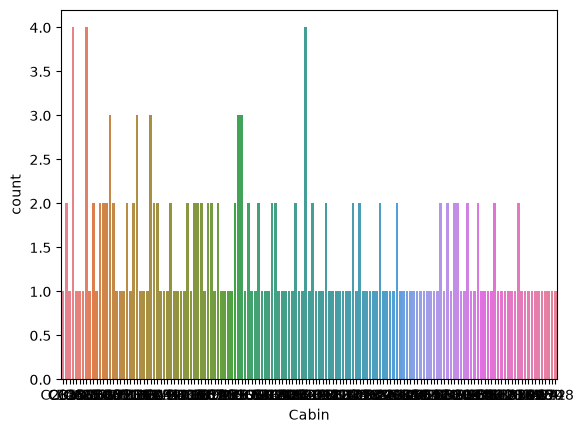

In [58]:
sns.countplot(x='Cabin', data=train_data, hue='Cabin', legend=False)
plt.show()

In [39]:
train_data['Cabin'].sample(10)

30      NaN
801     NaN
380     NaN
809      E8
889    C148
639     NaN
304     NaN
249     NaN
334     NaN
643     NaN
Name: Cabin, dtype: str

In [59]:
# Function to extract the deck information from the cabin column
def extract_cabin(data):
  data['Cabin'] = data['Cabin'].fillna('N')
  # Extract the first letter of the cabin to represent the deck
  data['Cabin'] = data['Cabin'].apply(lambda x: x[0])
  return

In [60]:
extract_cabin(train_data)
extract_cabin(test_data)

train_data['Cabin'].sample(10)

173    N
589    N
764    N
311    B
402    N
452    C
548    N
467    N
839    C
694    N
Name: Cabin, dtype: str

In [61]:
train_data['Fare'].sample(10)

444      8.1125
626     12.3500
219     10.5000
164     39.6875
644     19.2583
268    153.4625
590      7.1250
866     13.8583
399     12.6500
594     26.0000
Name: Fare, dtype: float64

In [63]:
# Function to categorize the fare into quantile-based bins
def cat_fare(data):
  data['Fare'] = data['Fare'].fillna(0.0)
  # Categorize the fare into bins
  cat_names = ['1st', '2nd', '3rd', '4th', '5th']
  data['Fare_cat'] = pd.qcut(data['Fare'], q=5, labels=cat_names)
  return

In [64]:
cat_fare(train_data)
cat_fare(test_data)

train_data['Fare_cat'].sample(10)

315    1st
123    3rd
193    4th
366    5th
791    4th
294    2nd
883    2nd
823    3rd
504    5th
850    4th
Name: Fare_cat, dtype: category
Categories (5, str): ['1st' < '2nd' < '3rd' < '4th' < '5th']